In [38]:
import torch
import torch.nn as nn
import train, test
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

SE CARGAN LOS CONJUNTOS DE DATOS

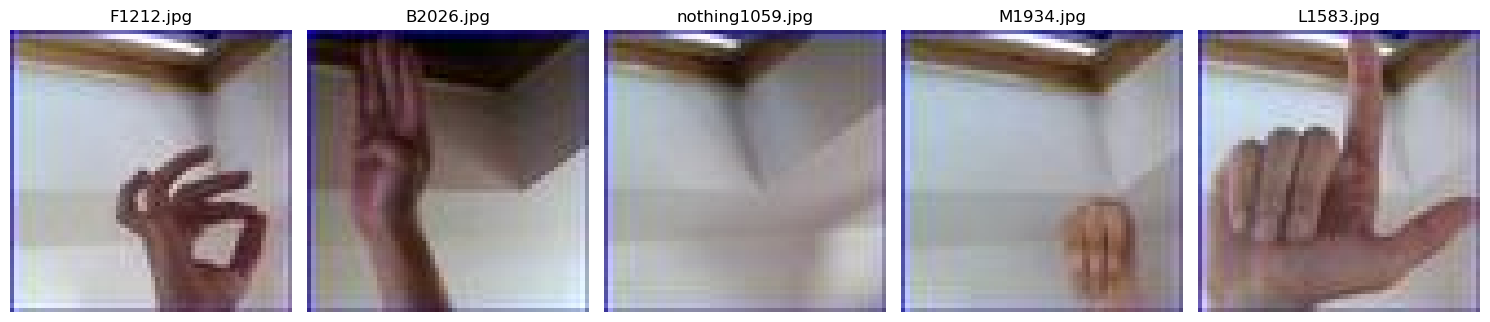

In [33]:
SEMILLA=42
ruta_train = Path("train")
ruta_test = Path("test")

images = list(ruta_train.glob("*.jpg"))
random.seed(SEMILLA)

selected_images = random.sample(images, k=min(5, len(images)))


plt.figure(figsize=(15, 4))
for i, image_path in enumerate(selected_images):
    image = Image.open(image_path)
    plt.subplot(1, len(selected_images), i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

MODELO RED NEURONAL SIMPLE

In [57]:
modelo_mlp = nn.Sequential(

    nn.Flatten(),

    nn.Linear(3 * 64 * 64, 512),
    nn.ReLU(),
    nn.Dropout(0.30),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.20),

    nn.Linear(128, 29)
)

MODELO RED NEURONAL CONVOLUCIONAL

In [60]:
modelo_cnn = nn.Sequential(

    # 3x64x64 -> 16x64x64
    nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 16x32x32
    nn.MaxPool2d(
        kernel_size=2,
        stride=2
    ),

    # -> 32x32x32
    nn.Conv2d(
        16,
        32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 32x16x16
    nn.MaxPool2d(2),

    # -> 64x16x16
    nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 64x8x8
    nn.MaxPool2d(2),

    # 64x8x8 -> 4096
    nn.Flatten(),

    nn.Linear(
        64 * 8 * 8,
        128
    ),
    nn.ReLU(),

    nn.Linear(
        128,
        29
    )
)

MODELO RED NEURONAL MEJORADA

In [61]:
modelo_cnn2 = nn.Sequential(

    # Bloque 1
    nn.Conv2d(
        3,
        32,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Bloque 2
    nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Bloque 3
    nn.Conv2d(
        64,
        128,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Global Average Pooling
    nn.AdaptiveAvgPool2d((1, 1)),

    # 128x1x1 -> 128
    nn.Flatten(),

    nn.Dropout(0.40),

    nn.Linear(
        128,
        29
    )
)

In [85]:
class ASLDataset(Dataset):

    def __init__(self, ruta, transform=None):

        self.ruta = Path(ruta)

        self.imagenes = sorted(
            self.ruta.glob("*.jpg")
        )

        self.transform = transform

        # Clases ASL
        self.clases = [
            "A", "B", "C", "D", "E", "F", "G",
            "H", "I", "J", "K", "L", "M", "N",
            "O", "P", "Q", "R", "S", "T", "U",
            "V", "W", "X", "Y", "Z",
            "del", "nothing", "space"
        ]

        self.clase_a_indice = {
            clase: i
            for i, clase in enumerate(self.clases)
        }

    def __len__(self):

        return len(self.imagenes)

    def __getitem__(self, idx):

        ruta_imagen = self.imagenes[idx]

        imagen = Image.open(
            ruta_imagen
        ).convert("RGB")

        # Extraer clase del nombre
        nombre = ruta_imagen.stem

        clase = self.clases[0]#nombre.split("_")[0]

        etiqueta = self.clase_a_indice[clase]

        if self.transform:
            imagen = self.transform(imagen)

        return imagen, etiqueta

In [86]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [87]:
from torchvision import transforms

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [88]:
train_dataset = ASLDataset(
    ruta="train",
    transform=transform
)

test_dataset = ASLDataset(
    ruta="test",
    transform=transform_test
)

In [89]:
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 17400
Test: 2928


In [90]:
imagen, etiqueta = train_dataset[0]

print(imagen.shape)
print(etiqueta)

torch.Size([3, 64, 64])
0


In [91]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

CONFIGURACIÓN DEL ENTRENAMIENTO

In [92]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

modelo1 = modelo_mlp.to(device)# modelo red neuronal simple

Dispositivo: cuda


In [93]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

modelo2 = modelo_cnn.to(device) #modelo cnn 1

Dispositivo: cuda


In [94]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

modelo3 = modelo_cnn2.to(device) #segundo modelo de cnn

Dispositivo: cuda


ENTRENAMIENTO

In [75]:
epochs = 10
def training(modelo, epochs,train_loader):
    criterio = nn.CrossEntropyLoss()#perdida
    optimizer = torch.optim.Adam(modelo.parameters(),lr=0.001) #optimizador

    train_losses = []
    train_accuracy = []

    for epoch in range(epochs):

        modelo.train()

        perdida_total = 0
        correctos = 0
        total = 0

        for imagenes, etiquetas in train_loader:

            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)

        # -------------------------
        # Reiniciar gradientes
        # -------------------------

            optimizer.zero_grad()

        # -------------------------
        # Forward
        # -------------------------

            salidas = modelo(imagenes)

        # -------------------------
        # Loss
        # -------------------------

            loss = criterio(salidas,etiquetas)

        # -------------------------
        # Backpropagation
        # -------------------------

            loss.backward()

        # -------------------------
        # Actualización
        # -------------------------

            optimizer.step()

            perdida_total += (loss.item()* imagenes.size(0))

            predicciones = salidas.argmax(dim=1)

            correctos += (predicciones == etiquetas).sum().item()

            total += etiquetas.size(0)

        loss_epoch = perdida_total / total

        accuracy_epoch = correctos / total

        train_losses.append(loss_epoch)

        train_accuracy.append(accuracy_epoch)
        print(f"Epoch {epoch+1}/{epochs} | " f"Loss: {loss_epoch:.4f} | "f"Accuracy: {accuracy_epoch:.4f}")
        return train_losses, train_accuracy, accuracy_epoch, loss_epoch

#print(f"Epoch {epoch+1}/{epochs} | " f"Loss: {loss_epoch:.4f} | "f"Accuracy: {accuracy_epoch:.4f}")

In [76]:
train_losses1, train_accuracy1, accuracy_epoch1, loss_epoch1=training(modelo1, epochs, train_loader)

Epoch 1/10 | Loss: 0.0000 | Accuracy: 1.0000


In [77]:
train_losses2, train_accuracy2, accuracy_epoch2, loss_epoch2=training(modelo2, epochs, train_loader)

Epoch 1/10 | Loss: 0.0185 | Accuracy: 0.9982


In [78]:
train_losses3, train_accuracy3, accuracy_epoch3, loss_epoch3=training(modelo3, epochs, train_loader)

Epoch 1/10 | Loss: 0.0784 | Accuracy: 0.9903


PRUEBA DE LOS MODELOS

In [79]:
def prueba(modelo, test_loader):
    modelo.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imagenes, etiquetas in test_loader:

            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)

            salidas = modelo(imagenes)

            predicciones = salidas.argmax(dim=1)

            y_true.extend(etiquetas.cpu().numpy())

            y_pred.extend(predicciones.cpu().numpy())
        
        return y_true, y_pred

In [95]:
y_true1, y_pred1=prueba(modelo1, test_loader)

In [96]:
y_true2, y_pred2=prueba(modelo2, test_loader)

In [97]:
y_true3, y_pred3=prueba(modelo3, test_loader)